In [3]:
import pandas as pd
df=pd.read_csv('train.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [ ]:
df.shape

(9800, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [6]:
df['Order Date']=pd.to_datetime(df['Order Date'],dayfirst=True)
df['Ship Date']=pd.to_datetime(df['Ship Date'],dayfirst=True)
df[['Order Date','Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [ ]:
df['Sales'].sum()

np.float64(2261536.7827000003)

In [ ]:
df.groupby('Category')['Sales'].sum()

,Sales
Category,
Furniture,728658.5757
Office Supplies,705422.3340
Technology,827455.8730


In [ ]:
Region_sale= df.groupby('Region')['Sales'].sum()
Region_sale.idxmax()


'West'

In [ ]:

df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(1)


,Sales
State,
California,446306.4635


In [26]:
Highest_City_sale=df[df['State']=='California']
Highest_City_sale.groupby('City')["Sales"].sum().sort_values(ascending=False).head(1)

,Sales
City,
Los Angeles,173420.181


In [24]:

Highest_month_sale=df.groupby(df['Order Date'].dt.month_name())['Sales'].sum().sort_values(ascending=False).head(1)
Highest_month_sale.index.name='Order Month'
Highest_month_sale

,Sales
Order Month,
November,350161.711


In [7]:
df.groupby([df['Order Date'].dt.month_name().rename('Month'),df['Order Date'].dt.year.rename('year')])['Sales'].sum().sort_values(ascending=False).head(1)


,,Sales
Month,year,
November,2018,117938.155


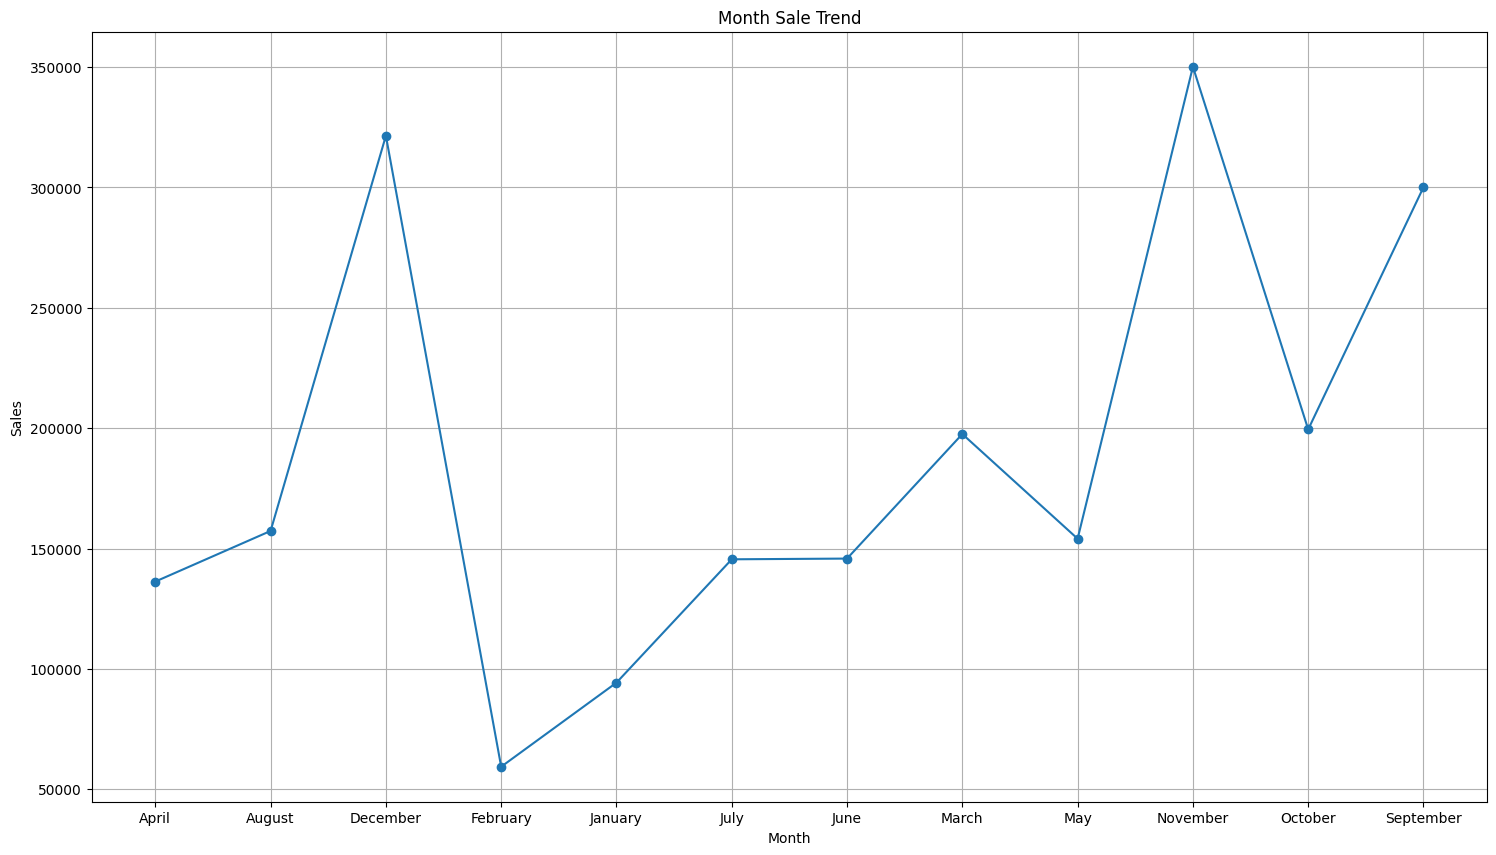

In [47]:
import matplotlib.pyplot as plt
plt.figure(figsize=(18,10))
MonSal=df.groupby(df['Order Date'].dt.month_name().rename('Order Month'))['Sales'].sum()
x=MonSal.index
y=MonSal.values
plt.plot(x,y,marker='o')
plt.title('Month Sale Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)


In [49]:
df.groupby(df['Order Date'].dt.year.rename('Order Year'))['Sales'].sum()


,Sales
Order Year,
2015,479856.2081
2016,459436.0054
2017,600192.5500
2018,722052.0192


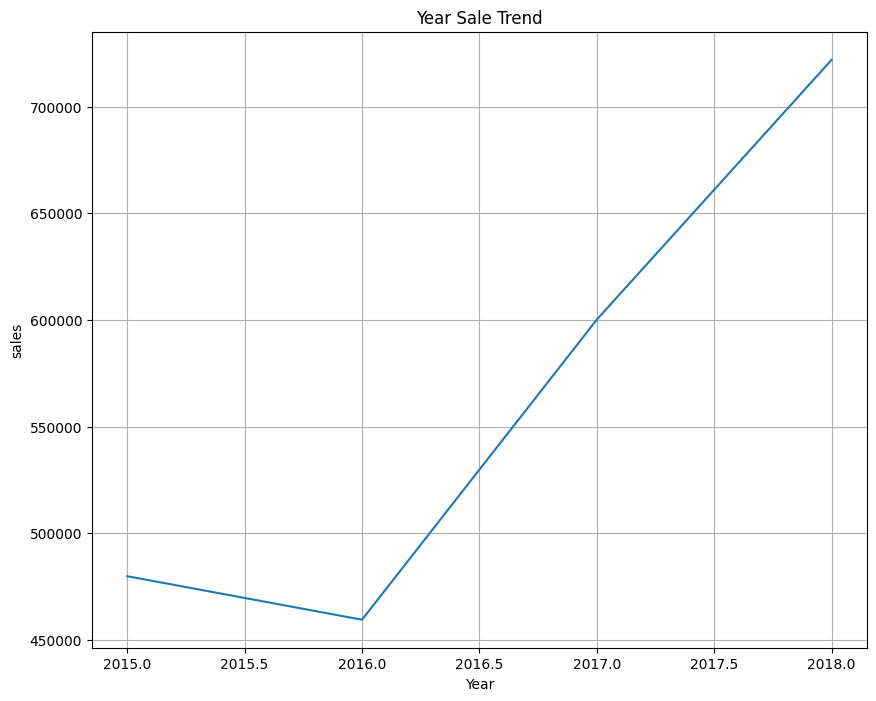

In [50]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
yearly_sales=df.groupby(df['Order Date'].dt.year.rename('Order Year'))['Sales'].sum()
plt.plot(yearly_sales.index,yearly_sales.values)
plt.xlabel('Year')
plt.ylabel('sales')
plt.title('Year Sale Trend')
plt.grid(True)

<Figure size 1500x600 with 0 Axes>

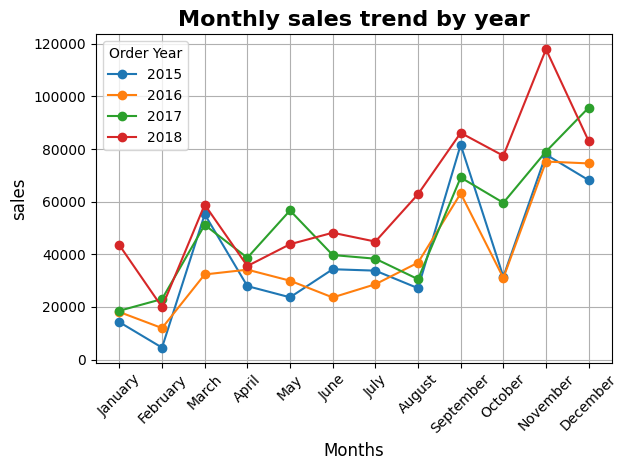

In [25]:
import matplotlib.pyplot as plt
import calendar
plt.figure(figsize=(15,6))
Monthly_sales=df.groupby([df['Order Date'].dt.year.rename('Order Year'),df['Order Date'].dt.month.rename('Order Month')])['Sales'].sum().unstack().T
Monthly_sales.index=[calendar.month_name[m] for m in Monthly_sales.index]
Monthly_sales.plot(marker='o')
plt.xlabel('Months',fontsize=12)
plt.ylabel('sales',fontsize=12)
plt.title('Monthly sales trend by year',fontsize=16,fontweight='bold')
plt.grid(True)
plt.xticks(ticks=range(len(Monthly_sales.index)),labels=Monthly_sales.index,rotation=45)
plt.tight_layout()
